**ToDo**:
 - сохранять фотки в том же формате что были
 - исправить ресайз для мелких картинов
 - посмотреть что с blur

In [353]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import SwinForImageClassification
import torch.nn as nn
import torch.multiprocessing as mp
import random
from typing import List, Optional, Callable, Union
from albumentations import (
    Compose, Rotate, RandomBrightnessContrast, GaussianBlur, 
    HorizontalFlip, VerticalFlip, RandomGamma, OpticalDistortion,
    RandomShadow, HueSaturationValue, ImageCompression, RandomScale,
    ShiftScaleRotate 
)

In [279]:
folder_path = "E:\\VYZ\\ICONS"
dataset_path = folder_path +"\\icons_dataset.csv"
images_path = folder_path +"\\images_mini"

In [151]:
df = pd.read_csv(dataset_path, sep=";", encoding = "utf-8")
df.head()

,id,Название,Реставрация,Размер,Автор,Материал,Персоналии,Уточняющая датировка,Век,Страна,Место хранения,"Иконография, категория",Тип изображения,Фрагменты
0,5581,Ангел из композиции Восстание из Гроба,NaN,"75,2 х 34",NaN,"Дерево, левкас, темпера",Ангел,XIX в Начало,19.0,Россия,Дом икон на Спиридоновке,Ангелы,Ростовое,NaN
1,4130,Да молчит всяка плоть человеча,NaN,"23,6 х 20,8",NaN,"дерево, левкас, темпера","Спаситель,Василий Великий, Иоанн Златоуст, Гри...",XVI в Конец,16.0,Россия,Ризница Покровского собора при Рогожском кладбище,Страстной и Пасхальный циклы,Сюжетная композиция,NaN
2,4135,Да молчит всяка плоть человеча,NaN,"231 х 157 (врезок 195,5 х 161,2",NaN,"дерево, левкас, темпера","Младенец, царь Иоанн Васильевич (Грозный), Мит...",XVI в Конец,16.0,Россия,Ризница Покровского собора при Рогожском кладбище,Страстной и Пасхальный циклы,Сюжетная композиция,NaN
3,4169,Да молчит всяка плоть человеча,NaN,"129,5 х 97,2",NaN,"дерево, левкас, темпера","Младенец, ангелы, Иоанн Креститель, святые",XVII в,17.0,Россия,Ризница Покровского собора при Рогожском кладбище,Страстной и Пасхальный циклы,Сюжетная композиция,NaN
4,5583,Иисус Христос из композиции Восстание из гроба,NaN,"94,5 х 45",NaN,"Дерево, левкас, темпера",Спаситель,XIX в Начало,19.0,Россия,Дом икон на Спиридоновке,Спаситель,Ростовое,NaN


## Аугментация

Вращение

In [340]:
def apply_rotation (images_path: str, target_path: Optional[str]= None, valid_ids: Optional[List[Union[int, str]]] = None,
                    angle: int = 15, p: float = 1.0, rand: bool = True, count: int = 1) -> None:
    """
    Вращение. 
    Сохраняются в виде imgId_aug_rot_num (пример: 123_aug_rot_1 = аугментация вращения номер 1 фотки под 123 айдишником)
    
    images_path - путь к папке с фотками
    target_path - путь куда сохранять аугментированные
    valid_ids - список id которые будут обработаны из images_path (иначе все)
    angle - угол поворота картинки 
    p - вероятность применения аугментации к изображению (от 0 до 1)
    rand - угол выбирается случайным образом от -rand до rand
    count - количество аугментаций каждой фотки
    """
    SUPPORTED_FORMATS = ('.jpg', '.jpeg', '.png')
    processed_count = 0
    all_count = 0
    
    with os.scandir(images_path) as entries:
        for entry in entries:
            if entry.is_file():
                all_count += 1
                
    if target_path is None:
        target_path = os.path.join(os.path.dirname(images_path), "images_path")
        
    if valid_ids is not None:
        valid_ids = set(str(id_) for id_ in valid_ids)
        all_count = len(valid_ids)
    
    os.makedirs(target_path, exist_ok=True)
    
    for file_name in tqdm(os.listdir(images_path), desc = 'aug_rotation'):
        
        if not file_name.lower().endswith(SUPPORTED_FORMATS):
            continue
    
        file_id = str(os.path.splitext(file_name)[0])
        if valid_ids is not None and file_id not in valid_ids:
            continue
            
        try:
            img_path = os.path.join(images_path, file_name)
            image = cv2.imread(img_path)
            if image is None:
                continue
            
            base_name, ext = os.path.splitext(file_name)
            
            for j in range(count):
                temp_angle = angle if rand is False else random.randint(-angle,angle)
                transform  = Compose([
                    Rotate(
                        limit = temp_angle,
                        p = p,
                        border_mode = cv2.BORDER_CONSTANT,
                        value = [255,255,255]
                    )
                ])
                
                aug_image = transform(image = image)["image"]
                
                new_file_name = f"{base_name}_aug_rot_{j+1}{ext}"
                output_path = os.path.join(target_path, new_file_name)
                cv2.imwrite(output_path, aug_image)
                processed_count +=1
        except Exception as e:
            print(f"Ошибка обрвботки файла {file_name}: {str(e)}")
            
    print(f"Обработано {processed_count} изображений из {all_count}")
    

Отзеркаливание

In [341]:
def apply_flip(images_path: str, target_path: Optional[str] = None, valid_ids: Optional[List[Union[int, str]]] = None,
               direction: str ='horizontal', p: float = 1.0, rand: bool= True, count: int = 1) -> None:
    """
    Отзеркаливание 
    Сохраняются в виде imgId_aug_flip_num (пример: 123_aug_flip_1 = аугментация отзеркаливания номер 1 фотки под 123 айдишником)
    
    images_path - путь к папке с фотками
    target_path - путь куда сохранять аугментированные
    valid_ids - список id которые будут обработаны из images_path (иначе все)
    direction - по вертикали или горизонтали 
    p - вероятность применения аугментации к изображению (от 0 до 1)
    rand - для каждой фотки рандомно выбирается вероятность ее отзеркаливание из horizontal, vertical и None не учитывая выбранный direction
    count - количество аугментаций каждой фотки
    """
    
    SUPPORTED_FORMATS = ('.jpg', '.jpeg', '.png')
    processed_count = 0
    all_count = 0
    
    with os.scandir(images_path) as entries:
        for entry in entries:
            if entry.is_file():
                all_count += 1
                
    if target_path is None:
        target_path = os.path.join(os.path.dirname(images_path), "images_path")
        
    if valid_ids is not None:
        valid_ids = set(str(id_) for id_ in valid_ids)
        all_count = len(valid_ids)
    
    os.makedirs(target_path, exist_ok=True)
    
    for file_name in tqdm(os.listdir(images_path), desc = 'aug_flip'):
        
        if not file_name.lower().endswith(SUPPORTED_FORMATS):
            continue
    
        file_id = str(os.path.splitext(file_name)[0])
        if valid_ids is not None and file_id not in valid_ids:
            continue
            
        try:
            img_path = os.path.join(images_path, file_name)
            image = cv2.imread(img_path)
            if image is None:
                continue
                
            base_name, ext = os.path.splitext(file_name)
                
            for j in range(count):
                temp_direction = direction if not rand else random.choice(["horizontal", "vertical"])
                if direction == "horizontal":
                    transform = Compose([HorizontalFlip(p=p)])
                elif direction == "vertical":
                    transform = Compose([VerticalFlip(p=p)])
                
                aug_image = transform(image = image)["image"]
                
                new_file_name = f"{base_name}_aug_flip_{j+1}{ext}"
                output_path = os.path.join(target_path, new_file_name)
                cv2.imwrite(output_path, aug_image)
                processed_count +=1
        except Exception as e:
            print(f"Ошибка обрвботки файла {file_name}: {str(e)}")
            
    print(f"Обработано {processed_count} изображений из {all_count}")       

заблюрить

In [349]:
def apply_blur(images_path: str, target_path: Optional[str] = None, valid_ids: Optional[List[Union[int, str]]] = None,
               strength: float = 0.3, p: float = 1.0, blur_limit: int = 5, count: int = 1) -> None:
    """
    блюр 
    Сохраняются в виде imgId_aug_blur_num (пример: 123_aug_blur_1 = аугментация блюра номер 1 фотки под 123 айдишником)
    
    images_path - путь к папке с фотками
    target_path - путь куда сохранять аугментированные
    valid_ids - список id которые будут обработаны из images_path (иначе все)
    strength - сила размытия
    p - вероятность применения аугментации к изображению (от 0 до 1)
    blur_limit - диапазон ядра размытия
    count - количество аугментаций каждой фотки
    """
    SUPPORTED_FORMATS = ('.jpg', '.jpeg', '.png')
    processed_count = 0
    all_count = 0
    
    with os.scandir(images_path) as entries:
        for entry in entries:
            if entry.is_file():
                all_count += 1
                
    if target_path is None:
        target_path = os.path.join(os.path.dirname(images_path), "images_path")
        
    if valid_ids is not None:
        valid_ids = set(str(id_) for id_ in valid_ids)
        all_count = len(valid_ids)
    
    os.makedirs(target_path, exist_ok=True)
    
    for file_name in tqdm(os.listdir(images_path), desc = 'aug_blur'):
        
        if not file_name.lower().endswith(SUPPORTED_FORMATS):
            continue
    
        file_id = str(os.path.splitext(file_name)[0])
        if valid_ids is not None and file_id not in valid_ids:
            continue
            
        try:
            img_path = os.path.join(images_path, file_name)
            image = cv2.imread(img_path)
            if image is None:
                continue
            
            base_name, ext = os.path.splitext(file_name)
                
            for j in range(count):
                strength = strength if strength is not None else random.uniform(0.5, 1.2)
                transform = Compose([GaussianBlur(blur_limit=blur_limit, p=p)])
                
                aug_image = transform(image = image)["image"]
                
                new_file_name = f"{base_name}_aug_blur_{j+1}{ext}"
                output_path = os.path.join(target_path, new_file_name)
                cv2.imwrite(output_path, aug_image)
                processed_count +=1
        except Exception as e:
            print(f"Ошибка обрвботки файла {file_name}: {str(e)}")
            
    print(f"Обработано {processed_count} изображений из {all_count}")    
 

Сдвиг

In [343]:
def apply_shift(images_path: str, target_path: Optional[str] = None, valid_ids: Optional[List[Union[int, str]]] = None,
    shift_limit: float = 0.2, p: float = 1.0, rand: bool = True, count: int = 1, fill_value: List[int] = [255, 255, 255]) -> None:
    """
    Сдвиг в разные стороны
    Сохраняются в виде imgId_aug_shift_num (пример: 123_aug_shift_1 = аугментация сдвига номер 1 фотки под 123 айдишником)

    images_path - путь к папке с фотками
    target_path - путь куда сохранять аугментированные
    valid_ids - список id которые будут обработаны из images_path (иначе все)
    shift_limit - максимальный сдвиг(от ширины/высоты изображения)
    p - вероятность применения аугментации
    rand - если True, сдвиг случайный в пределах shift_limit
    count - количество вариантов на каждое изображение
    fill_value - цвет заполнения краев 
    """
    SUPPORTED_FORMATS = ('.jpg', '.jpeg', '.png')
    processed_count = 0
    all_count = 0
    
    with os.scandir(images_path) as entries:
        for entry in entries:
            if entry.is_file() and entry.name.lower().endswith(SUPPORTED_FORMATS):
                all_count += 1
                
    if target_path is None:
        target_path = os.path.join(os.path.dirname(images_path), "images_path")
        
    if valid_ids is not None:
        valid_ids = set(str(id_) for id_ in valid_ids)
        all_count = min(all_count, len(valid_ids))
    
    os.makedirs(target_path, exist_ok=True)
    
    for file_name in tqdm(os.listdir(images_path), desc='aug_shift'):
        if not file_name.lower().endswith(SUPPORTED_FORMATS):
            continue
    
        file_id = str(os.path.splitext(file_name)[0])
        if valid_ids is not None and file_id not in valid_ids:
            continue
            
        try:
            img_path = os.path.join(images_path, file_name)
            image = cv2.imread(img_path)
            if image is None:
                continue
                
            base_name, ext = os.path.splitext(file_name)
                
            height, width = image.shape[:2]
            
            for j in range(count):
                if rand:
                    shift_x = random.uniform(-shift_limit, shift_limit) * width
                    shift_y = random.uniform(-shift_limit, shift_limit) * height
                else:
                    shift_x = shift_limit * width
                    shift_y = shift_limit * height
                
                transform = Compose([
                    ShiftScaleRotate(
                        shift_limit=(shift_x/width, shift_y/height),
                        scale_limit=0,
                        rotate_limit=0,
                        p=p,
                        border_mode=cv2.BORDER_CONSTANT,
                        value=fill_value
                    )
                ])
                
                augmented = transform(image=image)
                aug_image = augmented["image"]
                
                new_file_name = f"{base_name}_aug_shift_{j+1}{ext}"
                output_path = os.path.join(target_path, new_file_name)
                cv2.imwrite(output_path, aug_image)
                processed_count +=1
                
        except Exception as e:
            print(f"Ошибка обработки файла {file_name}: {str(e)}")
            
    print(f"Обработано {processed_count} изображений из {all_count}")

Применение функций аугментации

In [345]:
"""def apply_rotation (images_path: str, target_path: Optional[str]= None, valid_ids: Optional[List[Union[int, str]]] = None,
                    angle: int = 15, p: float = 1.0, rand: bool = True, count: int = 1) -> None:
"""
target_path = os.path.join(os.path.dirname(images_path), "rotation_images")
apply_rotation (images_path, target_path=target_path, angle = 30)

aug_rotation:   0%|                                                                            | 0/450 [00:00<?, ?it/s]C:\Users\vov04\AppData\Local\Temp\ipykernel_2512\475630411.py:53: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  Rotate(
aug_rotation: 100%|██████████████████████████████████████████████████████████████████| 450/450 [02:12<00:00,  3.39it/s]

Обработано 450 изображений из 450


Пример выполнения:
    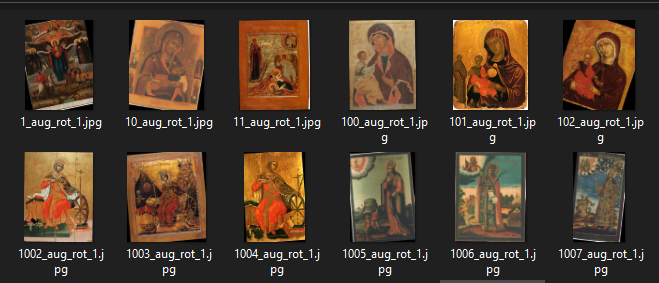
    

In [346]:
"""
def apply_flip(images_path: str, target_path: Optional[str] = None, valid_ids: Optional[List[Union[int, str]]] = None,
               direction: str ='horizontal', p: float = 1.0, rand: bool= True, count: int = 1) -> None:
   
"""
target_path = os.path.join(os.path.dirname(images_path), "flip_images")
apply_flip(images_path, target_path=target_path, rand=True)

aug_flip: 100%|██████████████████████████████████████████████████████████████████████| 450/450 [01:27<00:00,  5.15it/s]

Обработано 450 изображений из 450


Пример выполнения:
    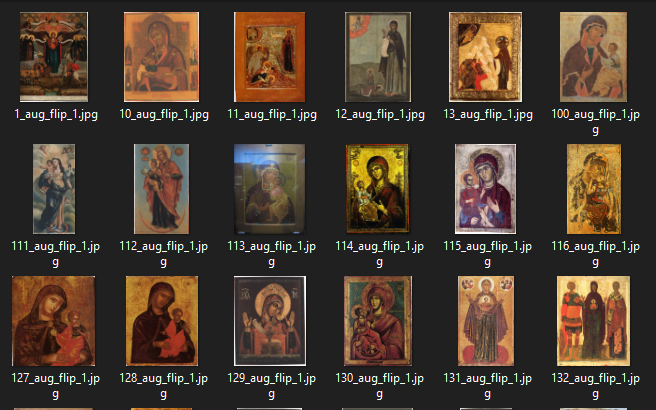

In [351]:
"""def apply_blur(images_path: str, target_path: Optional[str] = None, valid_ids: Optional[List[Union[int, str]]] = None,
               strength: float = 0.3, p: float = 1.0, blur_limit: bool = None, count: int = 1) -> None:
 """
target_path = os.path.join(os.path.dirname(images_path), "blur_images")
apply_blur(images_path, target_path=target_path, strength=3)

aug_blur:  67%|██████████████████████████████████████████████▊                       | 301/450 [01:14<00:36,  4.06it/s]


KeyboardInterrupt: 

In [355]:
"""
def apply_shift(images_path: str, target_path: Optional[str] = None, valid_ids: Optional[List[Union[int, str]]] = None,
    shift_limit: float = 0.2, p: float = 1.0, rand: bool = True, count: int = 1, fill_value: List[int] = [255, 255, 255]) -> None:
  """
target_path = os.path.join(os.path.dirname(images_path), "shift_images")
apply_shift(images_path, target_path=target_path, shift_limit=0.2)

aug_shift:   0%|                                                                               | 0/450 [00:00<?, ?it/s]C:\Users\vov04\AppData\Local\Temp\ipykernel_2512\3327524271.py:61: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  ShiftScaleRotate(
aug_shift: 100%|█████████████████████████████████████████████████████████████████████| 450/450 [01:43<00:00,  4.35it/s]

Обработано 450 изображений из 450


Пример выполнения:
    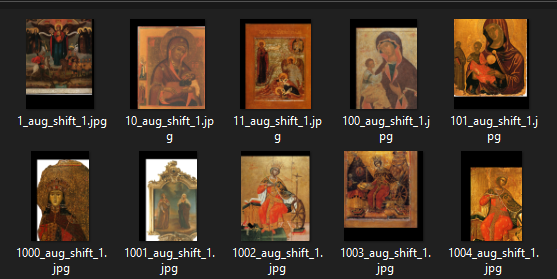
    
    лучше применять после ресайза, так фотки не обрежутся слишком сильно

## Ресайз

In [200]:
def resize_images(image_path, target_size = [1024,1024]):
    """
    Преобразование изображений к целевому значению с учетом пропорций 
    """
    image = Image.open(image_path)
    ratio = min(image.size[0]/target_size[0], image.size[1]/target_size[1])
    
    if (image.size[0]/target_size[0] > 1) or (image.size[1]/target_size[1] > 1):
        ratio = min(target_size[0]/image.size[0], target_size[1]/image.size[1])
    else:
        ratio = 1 + max(image.size[0]/target_size[0], image.size[1]/target_size[1]) - ratio
        
    new_size = (int(image.size[0] * ratio), int(image.size[1] * ratio))
    image = image.resize(new_size, Image.LANCZOS)
    
    new_image = Image.new("RGB", size = target_size ,color=(255,255,255))
    new_image.paste(image, ((target_size[0]-new_size[0])//2,
                            (target_size[1] - new_size[1])//2))
    return new_image
    

#### Выборочно тестируем, что функция отрабатывает верно

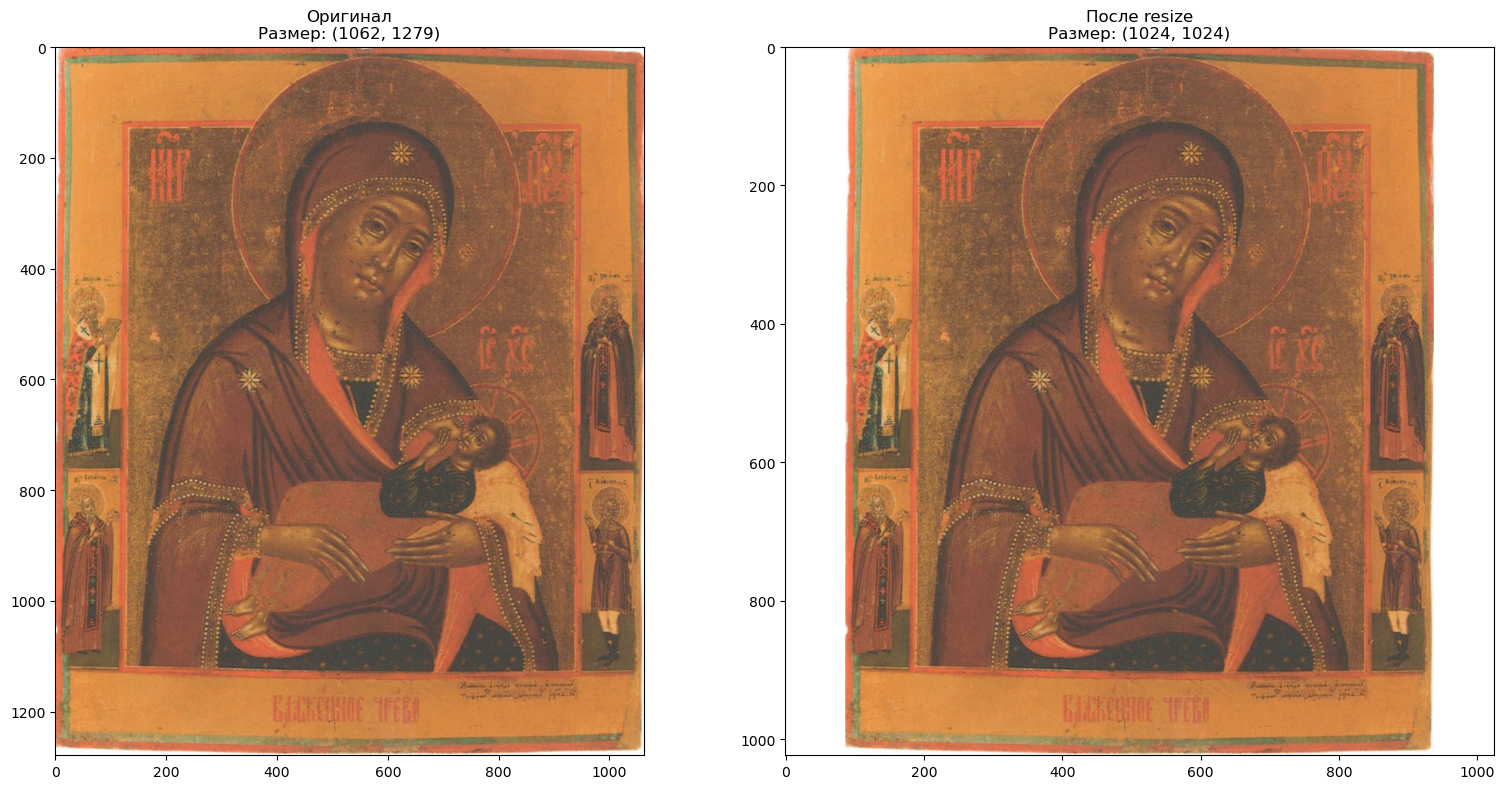

In [347]:
# тест масштабируемости 1063   1270   2204
"""
    1063   1270   2204 херово обработались, надо будет подправить 
    
"""
img_path = os.path.join(images_path, "1063.jpg")

original_img = Image.open(img_path)

plt.figure(figsize=(16, 8))

# --
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title(f"Оригинал\nРазмер: {original_img.size}")


# --
resized_img = resize_images(img_path, [1024, 1024])
plt.subplot(1, 2, 2)
plt.imshow(resized_img)
plt.title(f"После resize\nРазмер: {resized_img.size}")


plt.tight_layout()
plt.show()

In [202]:
def save_resize_images(images_path, target_path = None, target_size=[1024,1024], valid_ids = None, quality=95):
    """
    сохранение измененных фотографий в нужную директорию 
        valid_ids - позволяет изменить и сохранить в новую директорию только те фотограии, id которых, будут переданны, иначе обработаются и сохранятся все фотки
        target_size - размер к которому необходимо привести все фотки
        images_path - директория в которой все фотки
        target_path - директория в которую будут сохранены все фотки, по дефолту в родителькой images_path 'resized_images'
        quality - качество сохраненных фоток
    """
    SUPPORTED_FORMATS = ('.jpg', '.jpeg', '.png')
    processed_count = 0
    all_count = 0
    
    with os.scandir(images_path) as entries:
        for entry in entries:
            if entry.is_file():
                all_count += 1
            
    if target_path is None:
        target_path = os.path.join(os.path.dirname(images_path), "resized_images")
    
    if valid_ids is not None:
        valid_ids = set(str(id_) for id_ in valid_ids)
        all_count = len(valid_ids)
    
    os.makedirs(target_path, exist_ok=True)
    
    
    for file_name in tqdm(os.listdir(images_path)):
        
        if not file_name.lower().endswith(SUPPORTED_FORMATS):
            continue
    
        file_id = str(os.path.splitext(file_name)[0])
        if valid_ids is not None and file_id not in valid_ids:
            continue
            
        try:
            img_path = os.path.join(images_path,file_name)
            resizet_img = resize_images(img_path, target_size)
            output_path = os.path.join(target_path, file_name)
            resizet_img.save(output_path, quality=quality)
            processed_count += 1
        except Exception as e:
            print(f"Ошибка при обработке файла {file_name}: {str(e)}")
            
    print(f"Сохранено {processed_count} изображений из {all_count}")
    return True

#### Создаем список записей датасета, фотки которых есть на компе, попутно выводим все фотки 
cохранения списка записей имеющих фото + вывод в консоль фоточек для посмотреть
(можно и оставить, чтобы каждый раз по всем строкам не проходится, если не все фотки есть)

In [356]:
# сохранения списка записей имеющих фото + консольный вывод
#(не нужно при использовании полноценного датасета, но можно оставить для доп фильтрации лишних данных)
exists_rows_list = []
plt.figure(figsize=(10,6))

for idx, row in tqdm(df.iterrows(), total = len(df)):
    image_id = row["id"]
    image_path = os.path.join(images_path,f"{image_id}.jpg")
    
    if not os.path.exists(image_path):
        continue
    else:
        exists_rows_list.append(row) 
    
    img = Image.open(image_path)
    
    plt.imshow(img)
    
    info_text = (
        f"ID: {image_id}\n"
        f"Название: {row['Название']}\n"
    )
    
    plt.title(info_text,fontsize=10, pad=10)
    plt.show()
    
    

  0%|                                                                                          | 0/201 [00:01<?, ?it/s]


KeyboardInterrupt: 

#### Обновляем датасет оставляя только те записи, к которым есть фотки на компе 

In [210]:
df = pd.DataFrame(columns=df.columns)

In [213]:
# df с присутствующими фотографиями
df = pd.DataFrame(exists_rows_list).reset_index(drop=True)
df.head()

,id,Название,Реставрация,Размер,Автор,Материал,Персоналии,Уточняющая датировка,Век,Страна,Место хранения,"Иконография, категория",Тип изображения,Фрагменты
0,1,Азовская с предстоящими,NaN,NaN,NaN,"Дерево, левкас, темпера","Саваоф, Спаситель, Богоматерь, ангелы, ап. Пет...",18 в. Начало,18.0,Россия,"Государственный Исторический музей, Москва",Богоматерь,Ростовое с клеймами,"Азов, Кази-Кермен"
1,10,Блаженное Чрево,NaN,"31 x 26,5 см",Трофим Дорохов,"Дерево, темпера","Спаситель, Богоматерь",18 в. 1799 г.,18.0,Россия,"Государственный музей истории религии, Санкт-П...",Богоматерь,Поясное,NaN
2,13,Боголюбская,NaN,NaN,NaN,"Дерево, левкас, темпера","Спаситель, Богоматерь, молящиеся",16 в.,16.0,Россия,"Государственный Русский музей, Санкт-Петербург",Богоматерь,Ростовое,NaN
3,11,Боголюбская (левая створка трехстворчатого скл...,Реставрирована в 1981-1989 гг. во Всероссийско...,"22,6 х 17,8 см",NaN,"Дерево, левкас, темпера","Богородица, ангел хранитель, свт. Николай Чудо...",17 в. Около 1693 г.,17.0,Россия,Сольвычегодский историко-художественный музей,Богоматерь,Многофигурное,NaN
4,12,Боголюбская с припадающими святителем Алексием...,NaN,"110,3 х 78,8 см",NaN,"Дерево, левкас, темпера",NaN,17 в. Конец,17.0,Россия,Частное собрание Игоря Возякова,Богоматерь,Ростовое,NaN


#### Изменяем размер всех фоток и сохраняем их в папку рядом с прошлыми фотками 

In [304]:
# ресайз фоток и их сохранение
valid_ids = set(df['id'].astype(str))
#save_resize_images(images_path, target_path = None, target_size=[1024,1024], valid_ids = None, quality=95)
save_resize_images(images_path, target_size =[512,512], valid_ids=valid_ids)

100%|████████████████████████████████████████████████████████████████████████████████| 450/450 [01:04<00:00,  7.03it/s]

Сохранено 201 изображений из 201


True

## df info
проанализируем насыщенность данных датасета

In [250]:
df = df.dropna(subset=['Название', 'Век', 'Иконография, категория', 'Тип изображения'])

In [251]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447 entries, 0 to 446
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      447 non-null    int64  
 1   Название                447 non-null    object 
 2   Реставрация             195 non-null    object 
 3   Размер                  414 non-null    object 
 4   Автор                   86 non-null     object 
 5   Материал                443 non-null    object 
 6   Персоналии              427 non-null    object 
 7   Уточняющая датировка    447 non-null    object 
 8   Век                     447 non-null    float64
 9   Страна                  447 non-null    object 
 10  Место хранения          439 non-null    object 
 11  Иконография, категория  447 non-null    object 
 12  Тип изображения         447 non-null    object 
 13  Фрагменты               87 non-null     object 
dtypes: float64(1), int64(1), object(12)
memory

In [221]:
value_counts_name = df['Название'].value_counts()
value_counts_name

Название
Иоанн Предтеча (из деисусного чина)                         29
Иоанн Предтеча                                              27
Богоматерь с Младенцем                                      27
Екатерина великомученица                                    12
Иоанн Златоуст (из деисусного чина)                         10
                                                            ..
Иоанн Богослов и Александр Вочский (двусторонняя икона)      1
Иоанн Богослов с Прохором на осторове Патмос                 1
Иоанн Воин, в житии                                          1
Иоанн Златоуст (двухрядница, наверху Рождество Христово)     1
Чудесное насыщение народа                                    1
Name: count, Length: 212, dtype: int64

In [222]:
value_counts_century = df['Век'].value_counts()
value_counts_century

Век
16.0    121
17.0    105
18.0     84
15.0     53
14.0     33
19.0     31
13.0     12
12.0      4
20.0      2
10.0      2
Name: count, dtype: int64

#### Фильтруем датасет, оставляем только те записи, название которых встречается больше N раз и те, век которых встречатеся больше M раз
тк модель не смодет адекватно обучиться на малом количестве данных (*проверить*), то дропнем все, что имеет мало примеров
    

In [253]:
valid_name_values = value_counts_name[value_counts_name >= 5].index
valid_century_values = value_counts_century[value_counts_century >= 5].index

df = df[
    df['Название'].isin(valid_name_values) &
    df["Век"].isin(valid_century_values)
]
df.count()

id                        201
Название                  201
Реставрация                90
Размер                    181
Автор                      39
Материал                  199
Персоналии                194
Уточняющая датировка      201
Век                       201
Страна                    201
Место хранения            195
Иконография, категория    201
Тип изображения           201
Фрагменты                  41
dtype: int64

#### Кодируем текстовые метки через labelEncoder
юзаем отдельные кодировщики для каждого атрибута

In [288]:
label_encoders = {
    'name': LabelEncoder().fit(df['Название']),
    'century': LabelEncoder().fit(df['Век']),
    'category': LabelEncoder().fit(df['Иконография, категория']),
    'image_type': LabelEncoder().fit(df['Тип изображения'])
}

df['name_encoded'] = label_encoders['name'].transform(df['Название'])
df['century_encoded'] = label_encoders['century'].transform(df['Век'])
df['category_encoded'] = label_encoders['category'].transform(df['Иконография, категория'])
df['image_type_encoded'] = label_encoders['image_type'].transform(df['Тип изображения'])



LabelEncoder()


In [289]:
train_df, temp_df = train_test_split(df, test_size = 0.3, random_state = 123)
val_df, test_df = train_test_split(temp_df, test_size = 0.5, random_state = 123)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 140, Val: 30, Test: 31


## Swin Transformer

In [310]:
class ArtDataset(Dataset):
    def __init__(self, df,img_dir,  transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform or transforms.Compose([
            transforms.Resize((384, 384)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
     
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_id = str(self.df.iloc[idx]['id'])
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        image = Image.open(img_path)
        
        if self.transform:
            image = self.transform(image)
            
        return {
            'image': image,
            'name': torch.tensor(self.df.iloc[idx]['name_encoded'], dtype=torch.long),
            'century': torch.tensor(self.df.iloc[idx]['century_encoded'], dtype=torch.long),
            'category': torch.tensor(self.df.iloc[idx]['category_encoded'], dtype=torch.long),
            'image_type': torch.tensor(self.df.iloc[idx]['image_type_encoded'], dtype=torch.long),
        }
    
# Инициализация Dataset и DataLoader
train_dataset = ArtDataset(train_df, images_path)
val_dataset = ArtDataset(val_df, images_path)
test_dataset = ArtDataset(test_df, images_path)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
        

In [311]:
class MultiTaskSwin(nn.Module):
    def __init__(self, num_name_classes, num_century_classes, num_category_classes, num_image_type_classes):
        super().__init__()
        self.swin = SwinForImageClassification.from_pretrained(
            "microsoft/swin-tiny-patch4-window7-224"
        ).swin  # Берем только backbone
        
        # Heads для каждой задачи
        self.name_head = nn.Linear(768, num_name_classes)
        self.century_head = nn.Linear(768, num_century_classes)
        self.category_head = nn.Linear(768, num_category_classes)
        self.image_type_head = nn.Linear(768, num_image_type_classes)

    def forward(self, x):
        outputs = self.swin(x)
        pooled = outputs.last_hidden_state.mean(dim=1)  # Усреднение по spatial dimension
        
        return {
            'name': self.name_head(pooled),
            'century': self.century_head(pooled),
            'category': self.category_head(pooled),
            'image_type': self.image_type_head(pooled),
        }

# Инициализация модели
model = MultiTaskSwin(
    num_name_classes=len(label_encoders['name'].classes_),
    num_century_classes=len(label_encoders['century'].classes_),
    num_category_classes=len(label_encoders['category'].classes_),
    num_image_type_classes=len(label_encoders['image_type'].classes_),
)

In [312]:
# Упрощенный DataLoader с отключенной многопроцессорностью
train_loader = DataLoader(
    train_dataset,
    batch_size=16,  # Уменьшенный размер батча
    shuffle=True,
    num_workers=0,  # Важно для диагностики!
    pin_memory=True if torch.cuda.is_available() else False
)

# Запуск обучения
if __name__ == '__main__':
    for epoch in range(10):
        model.train()
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            try:
                images = batch['image'].to(device)
                names = batch['name'].to(device)
                centuries = batch['century'].to(device)
                categories = batch['category'].to(device)
                image_types = batch['image_type'].to(device)
                
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs['name'], names)  # + другие задачи
                loss.backward()
                optimizer.step()
            except Exception as e:
                print(f"Ошибка в батче: {e}")
                continue

Epoch 10: 100%|██████████████████████████████████████████████████████████████████████████| 9/9 [03:15<00:00, 21.77s/it]


In [313]:
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score

def decode_predictions(preds, label_encoder):
    """Декодирует предсказания с помощью LabelEncoder"""
    return label_encoder.inverse_transform(preds.cpu().numpy())

def evaluate_model(model, test_loader, label_encoders, device):
    """Полная оценка модели на тестовых данных"""
    model.eval()
    test_preds = []
    
    try:
        with torch.no_grad():
            # Отключаем tqdm для диагностики
            for batch in test_loader:  
                try:
                    # Переносим данные на устройство
                    images = batch['image'].to(device)
                    
                    # Получаем предсказания
                    outputs = model(images)
                    
                    # Собираем результаты для всех задач
                    batch_preds = {
                        'true_name': batch['name'].numpy(),
                        'pred_name': outputs['name'].argmax(dim=1).cpu().numpy(),
                        'true_century': batch['century'].numpy(),
                        'pred_century': outputs['century'].argmax(dim=1).cpu().numpy(),
                        'true_category': batch['category'].numpy(),
                        'pred_category': outputs['category'].argmax(dim=1).cpu().numpy(),
                        'true_image_type': batch['image_type'].numpy(),
                        'pred_image_type': outputs['image_type'].argmax(dim=1).cpu().numpy(),
                    }
                    test_preds.append(batch_preds)
                    
                except Exception as e:
                    print(f"Ошибка обработки батча: {str(e)}")
                    continue
        
        if not test_preds:
            raise RuntimeError("Не удалось обработать ни одного батча!")
        
        # Объединяем результаты
        results = {
            'name': {
                'true': np.concatenate([x['true_name'] for x in test_preds]),
                'pred': np.concatenate([x['pred_name'] for x in test_preds]),
            },
            'century': {
                'true': np.concatenate([x['true_century'] for x in test_preds]),
                'pred': np.concatenate([x['pred_century'] for x in test_preds]),
            },
            'category': {
                'true': np.concatenate([x['true_category'] for x in test_preds]),
                'pred': np.concatenate([x['pred_category'] for x in test_preds]),
            },
            'image_type': {
                'true': np.concatenate([x['true_image_type'] for x in test_preds]),
                'pred': np.concatenate([x['pred_image_type'] for x in test_preds]),
            }
        }
        
        # Вычисляем метрики
        metrics = {
            'name_accuracy': accuracy_score(results['name']['true'], results['name']['pred']),
            'century_accuracy': accuracy_score(results['century']['true'], results['century']['pred']),
            'category_accuracy': accuracy_score(results['category']['true'], results['category']['pred']),
            'image_type_accuracy': accuracy_score(results['image_type']['true'], results['image_type']['pred']),
        }
        
        # Примеры предсказаний
        sample_results = {
            'true_name': decode_predictions(torch.tensor(results['name']['true'][:5]), label_encoders['name']),
            'pred_name': decode_predictions(torch.tensor(results['name']['pred'][:5]), label_encoders['name']),
            'true_century': decode_predictions(torch.tensor(results['century']['true'][:5]), label_encoders['century']),
            'pred_century': decode_predictions(torch.tensor(results['century']['pred'][:5]), label_encoders['century']),
        }
        
        return metrics, sample_results
    
    except Exception as e:
        print(f"Критическая ошибка при оценке модели: {str(e)}")
        return None, None

# Перед оценкой модели:
if __name__ == '__main__':
    # 1. Убедимся, что DataLoader работает в однопроцессорном режиме
    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False,
        num_workers=0,  # Важно! Отключаем многопроцессорность
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    # 2. Проверим, есть ли данные в загрузчике
    print(f"Количество батчей в test_loader: {len(test_loader)}")
    
    # 3. Запуск оценки
    metrics, samples = evaluate_model(model, test_loader, label_encoders, device)
    
    if metrics and samples:
        print("\nМетрики модели:")
        for metric, value in metrics.items():
            print(f"{metric}: {value:.4f}")

        print("\nПримеры предсказаний:")
        print("Названия:")
        print(f"Истинные: {samples['true_name']}")
        print(f"Предсказанные: {samples['pred_name']}")

        print("\nВек:")
        print(f"Истинные: {samples['true_century']}")
        print(f"Предсказанные: {samples['pred_century']}")
    else:
        print("Не удалось получить результаты оценки!")

Количество батчей в test_loader: 2

Метрики модели:
name_accuracy: 0.0000
century_accuracy: 0.0968
category_accuracy: 0.0968
image_type_accuracy: 0.1613

Примеры предсказаний:
Названия:
Истинные: ['Иоанн Предтеча (из деисусного чина)' 'Иоанн Предтеча'
 'Екатерина великомученица' 'Иоанн Златоуст' 'Екатерина великомученица']
Предсказанные: ['Иоанн Златоуст' 'Иоанн Златоуст' 'Иоанн Златоуст' 'Иоанн Предтеча'
 'Иоанн Златоуст']

Век:
Истинные: [16. 15. 16. 15. 18.]
Предсказанные: [15. 19. 15. 13. 15.]
